# Online reinforcement learning for S&P 500 investing
### Signed stock and cash allocations, one policy update per day

**Goal:** choose long/short stock exposure and long/short cash exposure from past daily prices, using net portfolio return as the reward. The example trades simulated **SPY** exposure using Alpaca history. It learns sequentially; it never learns from a day's reward before that day has been scored.

The implementation is in `online_rl.py`. This notebook explains the mathematics, demonstrates individual updates, and inspects the saved full historical run. No brokerage orders are placed.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path.cwd()
FOLDER = BASE / "SP500" if (BASE / "SP500" / "online_rl.py").exists() else BASE
sys.path.insert(0, str(FOLDER))
from online_rl import Config, OnlinePortfolio, replay, load_prices, metrics

DATA = FOLDER / "data" / "SPY_daily.csv"
OUT = FOLDER / "outputs"
prices = load_prices(DATA)
model = OnlinePortfolio.load(OUT / "checkpoint.json")
cfg = model.config
summary = json.loads((OUT / "evaluation.json").read_text())
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False})
print(f"{len(prices):,} SPY sessions: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Saved online updates: {model.agent.updates:,}; last consumed session: {model.history[-1]['date']}")
display(prices.tail())

2,691 SPY sessions: 2016-01-04 to 2026-09-16
Saved online updates: 2,631; last consumed session: 2026-09-16


,open,close,raw_close
date,,,
2026-09-10,758.030,757.83,757.83
2026-09-11,764.720,764.29,764.29
2026-09-14,759.000,760.88,760.88
2026-09-15,760.117,757.39,757.39
2026-09-16,759.500,754.05,754.05


## 1. Stock and cash must satisfy the funding constraint

Let $E_t$ be equity and $w_t$ the target stock weight. For an execution price $P$ and equity **after** transaction costs $E^+$:

$$x=\frac{w_t E^+}{P}, \qquad y=(1-w_t)E^+, \qquad xP+y=E^+.$$

$x$ is signed stock units; $y$ is signed cash dollars. Negative stock means a short position. Negative cash means borrowing. The two amounts cannot be chosen independently without adding another source or use of capital.

The default discrete action grid is $w\in\{-1,-0.5,0,0.5,1,1.5,2\}$. It is configurable within the implemented leverage bounds. These are **target positions**, not buy/sell increments. The order is the difference from the existing position. At $w=0$, the target is all cash; at $w=1.5$, the target is 150% stock and −50% cash.

,stock_weight,cash_weight,stock_dollars_on_100k,cash_dollars_on_100k
0,-1.00,2.00,"-100,000.00","200,000.00"
1,-0.50,1.50,"-50,000.00","150,000.00"
2,0.00,1.00,0.00,"100,000.00"
3,0.50,0.50,"50,000.00","50,000.00"
4,1.00,0.00,"100,000.00",0.00
5,1.50,-0.50,"150,000.00","-50,000.00"
6,2.00,-1.00,"200,000.00","-100,000.00"


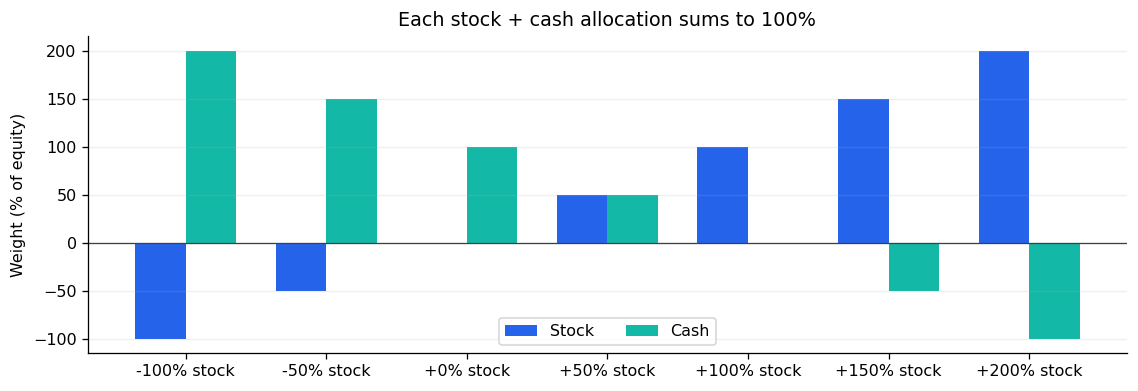

In [2]:
actions = pd.DataFrame({"stock_weight": cfg.weights, "cash_weight": 1-np.array(cfg.weights)})
actions["stock_dollars_on_100k"] = actions.stock_weight * 100000
actions["cash_dollars_on_100k"] = actions.cash_weight * 100000
display(actions.style.format({c: "{:,.2f}" for c in actions.columns}))

x = np.arange(len(actions))
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(x-.18, actions.stock_weight*100, .36, color="#2563eb", label="Stock")
ax.bar(x+.18, actions.cash_weight*100, .36, color="#14b8a6", label="Cash")
ax.axhline(0, color="#374151", linewidth=.8)
ax.set(xticks=x, xticklabels=[f"{w:+.0%} stock" for w in cfg.weights],
       ylabel="Weight (% of equity)", title="Each stock + cash allocation sums to 100%")
ax.legend(ncol=2)
ax.grid(axis="y", alpha=.2)
plt.tight_layout(); plt.show()

## 2. Observe, act, execute, score, learn

| Time | Information/action |
|---|---|
| Close of $t$ | Observe history through $t$ and current account; sample and save $a_t$ |
| Overnight | Existing holdings earn the close-to-open move; accrue financing |
| Open of $t+1$ | Execute the saved target allocation with costs |
| Close of $t+1$ | Mark the portfolio; calculate realized daily reward |
| After scoring $t+1$ | Update actor and critic once; choose the next action |

**Reward is net arithmetic return**, without a separate risk penalty:

$$r_{t+1}=\frac{E_{t+1}}{E_t}-1.$$

Borrowing, short-stock fees and trading costs all reduce equity and therefore reward. With adjusted open/close prices, the prior stock value first grows by $O_{t+1}/C_t$; the rebalanced value then grows by $C_{t+1}/O_{t+1}$. A first purchase at the next open cannot profit from the preceding overnight gap.

For proportional cost $k$, the implementation solves the self-financing equation

$$E^+=E^- - k\left|wE^+-S^-\right|,$$

where $S^-$ and $E^-$ are stock value and equity just before the trade. Costs are not silently financed by creating cash.

## 3. Online actor-critic

The policy is a softmax over a linear score for each allocation:

$$\pi_\theta(a\mid s)=\frac{\exp(\theta_a^\top\widetilde{s})}{\sum_b\exp(\theta_b^\top\widetilde{s})}, \qquad V_\phi(s)=\phi^\top\widetilde{s}.$$

$\widetilde{s}$ appends a bias. State contains 20 past log returns, 5/20-session momentum and volatility, trailing drawdown, stock/cash weights and log equity. Fixed feature scales avoid fitting on future data.

After observing one new daily transition, compute a TD(0) error:

$$\delta_t=100r_{t+1}+\gamma V_\phi(s_{t+1})-V_\phi(s_t),\qquad\gamma=0.95.$$

Then update the actor along $\delta_t\nabla_\theta\log\pi_\theta(a_t\mid s_t)$ plus a small entropy gradient, and update the critic toward the TD target. Adam state is retained across days. The bootstrap is disabled on bankruptcy. The TD error used for gradients is clipped to ±10 and gradient norms to 1.

The reward multiplier changes learning units; reported returns are unscaled. This is one on-policy update per day, with no replay buffer, repeated epochs or hindsight action labels. The reward objective is expected discounted net returns; clipping and finite data do not guarantee an optimal portfolio.

In [3]:
# A small chronological example: no writes and no mutation of the delivered model.
demo = OnlinePortfolio(Config(seed=42))
demo.initialize(prices.iloc[:60])
first_decision = demo.decision()
print("Initial signal date:", first_decision["as_of_close"])
print("Initial selected stock weight:", first_decision["selected_action"]["stock_weight"])
rows = []
for date, row in prices.iloc[60:65].iterrows():
    result = demo.advance(date, row)
    rows.append({k: result[k] for k in ["decision_date", "session", "stock_target_weight",
                "cash_target_weight", "reward_net_return", "equity", "policy_version_used", "updates_after"]})
display(pd.DataFrame(rows))
assert demo.agent.updates == 5
print("Five new completed sessions produced exactly five policy updates.")

Initial signal date: 2016-03-30
Initial selected stock weight: 1.5


,decision_date,session,stock_target_weight,cash_target_weight,reward_net_return,equity,policy_version_used,updates_after
0,2016-03-30,2016-03-31,1.5,-0.5,-0.003572,99642.830356,0,1
1,2016-03-31,2016-04-01,0.5,0.5,-0.002869,99356.991047,1,2
2,2016-04-01,2016-04-04,2.0,-1.0,-0.006622,98699.010958,2,3
3,2016-04-04,2016-04-05,1.0,0.0,-0.018294,96893.381526,3,4
4,2016-04-05,2016-04-06,-1.0,2.0,-0.011001,95827.457317,4,5


Five new completed sessions produced exactly five policy updates.


## 4. Persistent daily continuation

`checkpoint.json` stores the model, Adam moments, RNG, account balances, pending action, processed-data digest and ledger. The next action is already sampled and saved; reading `predict` does not sample a different action. A resumed run reproduces an uninterrupted run.

From the project folder, after a new session is complete:

```text
python SP500/download_data.py --append
python SP500/online_rl.py update
python SP500/online_rl.py predict
```

These commands do not schedule themselves. The algorithm updates when new completed data is supplied. Repeated input produces zero updates. Multiple missed sessions are processed in order. Processed history is checked before continuation; append mode accommodates a uniform corporate-action adjustment rescaling while preserving old observations.

In [4]:
# Repeating the same input is an idempotent read/continue operation.
reloaded = OnlinePortfolio.load(OUT / "checkpoint.json")
before = reloaded.agent.updates
new_sessions = reloaded.ingest(prices)
assert new_sessions == 0 and reloaded.agent.updates == before
print("New sessions:", new_sessions, "| updates unchanged:", before)
display(pd.DataFrame([{
    "actor learning rate": cfg.actor_lr, "critic learning rate": cfg.critic_lr,
    "trading cost (bps)": cfg.transaction_bps, "cash lending APR": cfg.cash_lending_rate,
    "cash borrowing APR": cfg.cash_borrow_rate, "stock borrowing APR": cfg.stock_borrow_rate,
    "maintenance margin": cfg.maintenance_margin
}]))

New sessions: 0 | updates unchanged: 2631


,actor learning rate,critic learning rate,trading cost (bps),cash lending APR,cash borrowing APR,stock borrowing APR,maintenance margin
0,0.0003,0.001,5.0,0.0,0.06,0.03,0.25


## 5. Historical sequential evaluation

The original run uses 60 sessions for feature warm-up, then one pass through all subsequent sessions. The reporting window starts in 2024. Each day's result is recorded **before** learning from it, and the agent continues learning during the reporting period. This is an **adaptive sequential evaluation**, not a frozen-policy test.

Baselines use the same timing, trading costs and financing assumptions. The 100% stock baseline becomes buy-and-hold; the 150% stock baseline rebalances with borrowing. Results use one seed and one realized price path. No hyperparameters were tuned on this reporting window. Curves below are normalized to each strategy's own starting equity in that window.

,sessions,return,max_drawdown,sharpe_252_zero_hurdle,margin_calls
online_actor_critic,679,0.42722,-0.166521,0.84966,0
cash,679,0.0,0.0,None,0
long_100pct,679,0.634372,-0.187557,1.245916,0
long_150pct,679,0.874087,-0.275497,1.113599,0


**Online agent: 42.72%; 100% SPY: 63.44%.** The agent underperformed holding SPY.

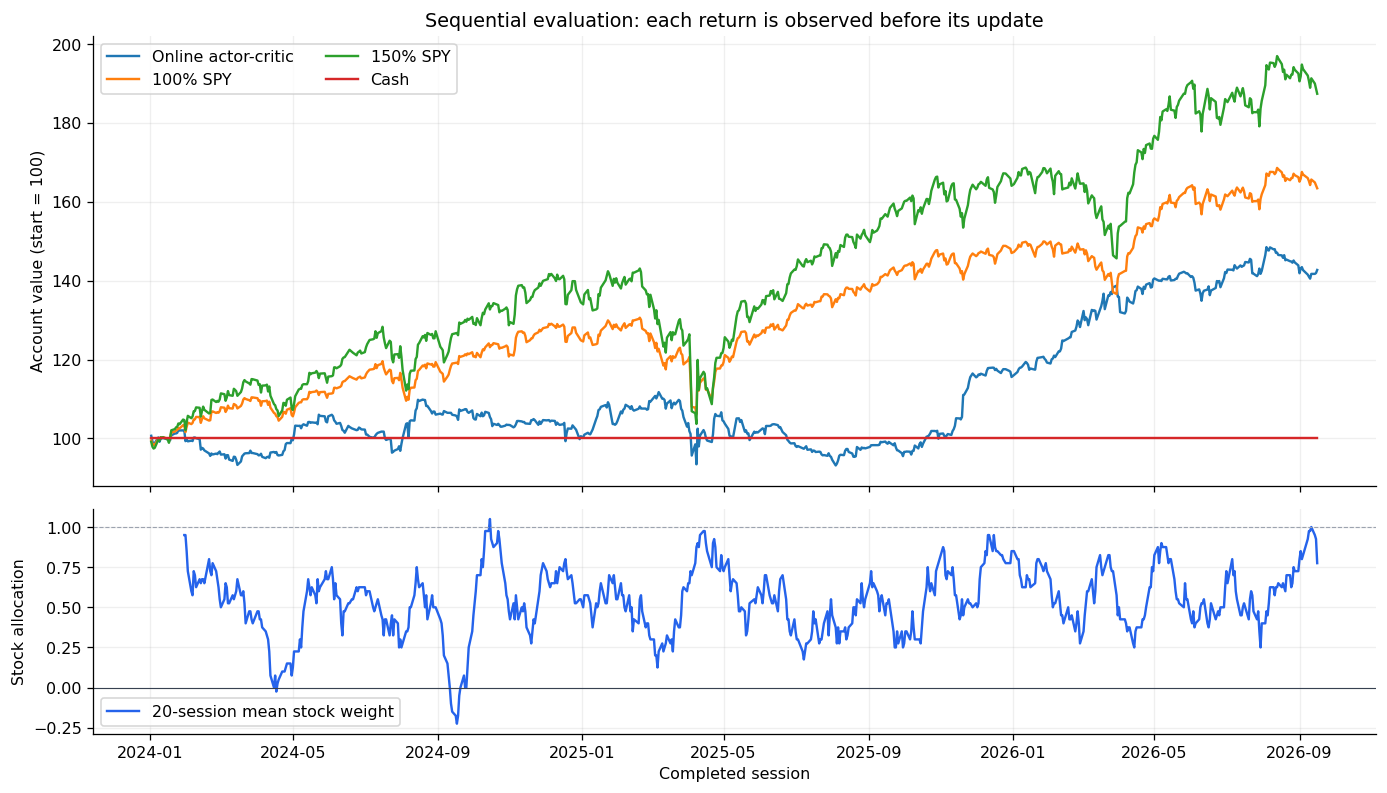

In [5]:
table = pd.DataFrame(summary["evaluation_period"]).T
display(table[["sessions", "return", "max_drawdown", "sharpe_252_zero_hurdle", "margin_calls"]])
agent_return = table.loc["online_actor_critic", "return"]
hold_return = table.loc["long_100pct", "return"]
display(Markdown(f"**Online agent: {agent_return:.2%}; 100% SPY: {hold_return:.2%}.** "
                 + ("The agent underperformed holding SPY." if agent_return < hold_return else
                    "This single run is insufficient to establish a durable advantage.")))

paths = {"Online actor-critic": "daily_learning.csv", "100% SPY": "baseline_long_100pct.csv",
         "150% SPY": "baseline_long_150pct.csv", "Cash": "baseline_cash.csv"}
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for label, filename in paths.items():
    frame = pd.read_csv(OUT / filename, parse_dates=["session"])
    frame = frame.loc[frame.session >= pd.Timestamp(summary["evaluation_start"])]
    # Restrict derived exports to the original replay report if the online state is later updated.
    final = summary["evaluation_period"]["online_actor_critic"]["last_session"]
    frame = frame.loc[frame.session <= pd.Timestamp(final)]
    axes[0].plot(frame.session, 100*frame.equity/frame.equity_before.iloc[0], label=label)
    if label == "Online actor-critic":
        online = frame
axes[0].set(title="Sequential evaluation: each return is observed before its update", ylabel="Account value (start = 100)")
axes[0].legend(ncol=2)
axes[1].plot(online.session, online.stock_target_weight.rolling(20).mean(), color="#2563eb", label="20-session mean stock weight")
axes[1].axhline(0, color="#374151", linewidth=.7)
axes[1].axhline(1, color="#9ca3af", linestyle="--", linewidth=.7)
axes[1].set(ylabel="Stock allocation", xlabel="Completed session")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(OUT / "equity_and_learning.png", dpi=150)
plt.show()

## 6. Latest allocation distribution

The following probabilities come from the persistent checkpoint. They are probabilities of **selecting allocations**, not confidence that those allocations will earn money. The selected action is sampled from that distribution; it is not necessarily the most probable action. Signed stock and cash amounts are indicative at the latest close, before the next open and its costs are known.

As of: 2026-09-16 | policy version: 2631


,stock_weight,cash_weight,probability,estimated_stock_dollars,estimated_stock_units,estimated_cash_dollars
0,-1.0,2.0,0.127428,-63208.577085,-83.825445,126417.154171
1,-0.5,1.5,0.136520,-31604.288543,-41.912723,94812.865628
2,0.0,1.0,0.149058,0.000000,0.000000,63208.577085
3,0.5,0.5,0.127834,31604.288543,41.912723,31604.288543
4,1.0,0.0,0.162760,63208.577085,83.825445,0.000000
5,1.5,-0.5,0.142923,94812.865628,125.738168,-31604.288543
6,2.0,-1.0,0.153476,126417.154171,167.650891,-63208.577085


Saved sampled stock weight: 0.5


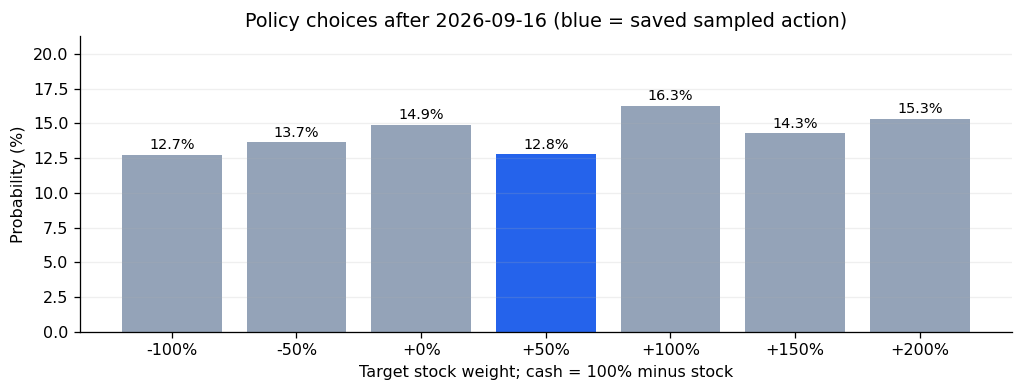

In [6]:
decision = model.decision()
print("As of:", decision["as_of_close"], "| policy version:", decision["policy_version"])
distribution = pd.DataFrame(decision["actions"])
display(distribution[["stock_weight", "cash_weight", "probability", "estimated_stock_dollars",
                      "estimated_stock_units", "estimated_cash_dollars"]])
print("Saved sampled stock weight:", decision["selected_action"]["stock_weight"])

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#2563eb" if a == decision["selected_action"]["action_index"] else "#94a3b8" for a in distribution.action_index]
bars = ax.bar([f"{w:+.0%}" for w in distribution.stock_weight], distribution.probability*100, color=colors)
for bar, p in zip(bars, distribution.probability):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.4, f"{p:.1%}", ha="center", fontsize=9)
ax.set(title=f"Policy choices after {decision['as_of_close']} (blue = saved sampled action)",
       xlabel="Target stock weight; cash = 100% minus stock", ylabel="Probability (%)")
ax.set_ylim(0, distribution.probability.max()*100+5)
ax.grid(axis="y", alpha=.2)
plt.tight_layout(); plt.show()

## 7. Scope and extensions

- **Costs:** default 5 bps trading cost, 0% cash yield, 6% cash borrowing and 3% stock borrowing APR are explicit assumptions. Financing uses elapsed calendar days. They are not live broker rates.
- **Execution:** fractional positions, adjusted total-return prices, next-open fills and daily marks are approximations. Locates, collateral restrictions, taxes, intraday liquidation, spreads changing with stress, and actual fills need a broker-aware extension.
- **Margin:** close-based 25% equity/absolute-stock maintenance; bankrupt accounts stop at zero. Real leveraged losses may exceed initial equity.
- **Data:** custom CSVs need consistently adjusted daily open and close. A spot S&P 500 index dataset produces theoretical index exposure; SPY provides an ETF proxy with its own tracking and costs.
- **Research:** additional seeds, forward paper operation and realistic execution assumptions are needed before judging usefulness. Avoid repeatedly choosing hyperparameters from the same later window.

Run the accounting, gradient, causality, idempotency and restart tests:

```text
python -m unittest discover -s SP500 -p test_online_rl.py -v
```

References: [policy gradients](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html), [SPY fund](https://www.ssga.com/us/en/individual/etfs/state-street-spdr-sp-500-etf-trust-spy), [Alpaca historical bars](https://docs.alpaca.markets/reference/stockbars).